# 02 — Supervised modeling and blocked-vs-shuffled cross-validation

This notebook trains the four supervised models in the COGS 109 Spring
2026 methods palette (LDA, KNN, PCA→LDA, and PCR-as-classifier) on the
frozen preprocessing artifacts from `notebooks/01_eda.ipynb`. The
headline result is a side-by-side comparison of accuracy under two
cross-validation schemes:

* **shuffled** 5-fold CV — the standard `KFold(shuffle=True)` recipe,
  which on a strongly autocorrelated time series leaks neighboring
  samples across the train/test boundary and inflates the apparent
  generalisation accuracy;
* **blocked** 5-fold CV — contiguous time blocks, which respects the
  ~117-second single-subject recording structure and gives an honest
  estimate.

Both fold-index files were frozen in `data/processed/cv_folds.json`
during preprocessing, so the comparison below is reproducible by
anyone re-running this notebook from a clean checkout.


## Setup — load the frozen Phase A splits and CV folds

The processed CSVs and fold index file are written by
`scripts/preprocess.py`; the modeling code never recomputes them.
We pull the 14-channel z-scored features for the chronological train
and test partitions and the precomputed blocked / shuffled fold
indices on the training partition.


In [1]:
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.data import CHANNELS, LABEL_COL
from src.models import fit_lda, fit_knn, fit_pca_lda, fit_pcr_classifier, score, PCRClassifier
from src.evaluate import cv_score, final_holdout_score
from src.plotting import apply_style, save_fig

apply_style()
sns.set_palette('deep')

PROC_DIR = os.path.join(REPO_ROOT, 'data', 'processed')
FIG_DIR = os.path.join(REPO_ROOT, 'figures')
TABLE_DIR = os.path.join(REPO_ROOT, 'tables')
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

train = pd.read_csv(os.path.join(PROC_DIR, 'eeg_train.csv'))
test = pd.read_csv(os.path.join(PROC_DIR, 'eeg_test.csv'))
X_train = train[list(CHANNELS)].to_numpy()
y_train = train[LABEL_COL].to_numpy().astype(int)
X_test = test[list(CHANNELS)].to_numpy()
y_test = test[LABEL_COL].to_numpy().astype(int)

with open(os.path.join(PROC_DIR, 'cv_folds.json')) as f:
    folds_blob = json.load(f)
blocked_folds = [
    (np.asarray(tr, dtype=np.int64), np.asarray(te, dtype=np.int64))
    for tr, te in folds_blob['blocked']
]
shuffled_folds = [
    (np.asarray(tr, dtype=np.int64), np.asarray(te, dtype=np.int64))
    for tr, te in folds_blob['shuffled']
]

print('train shape:', X_train.shape, 'test shape:', X_test.shape)
print('train class balance:', dict(pd.Series(y_train).value_counts()))
print('test class balance:', dict(pd.Series(y_test).value_counts()))
print('blocked folds:', len(blocked_folds), 'shuffled folds:', len(shuffled_folds))

train shape: (11917, 14) test shape: (2995, 14)
train class balance: {1: 6378, 0: 5539}
test class balance: {0: 2715, 1: 280}
blocked folds: 5 shuffled folds: 5


## Section A — Reference baselines

Two reference baselines that any trained model must clear to be
considered useful: predicting the global majority class (eyes-open,
label `0`) and predicting uniformly at random. Reported on the
blocked 5-fold CV folds for a like-for-like comparison.


In [2]:
from src.models import score as score_fn

class MajorityClass:
    def fit(self, X, y):
        vals, cnts = np.unique(y, return_counts=True)
        self.majority_ = int(vals[np.argmax(cnts)])
        return self
    def predict(self, X):
        return np.full(len(X), self.majority_, dtype=int)

class RandomGuess:
    def __init__(self, seed=42):
        self.seed = seed
    def fit(self, X, y):
        return self
    def predict(self, X):
        rng = np.random.default_rng(self.seed)
        return rng.integers(0, 2, size=len(X)).astype(int)

baseline_majority_blocked = cv_score(MajorityClass, X_train, y_train, blocked_folds)
baseline_random_blocked = cv_score(lambda: RandomGuess(42), X_train, y_train, blocked_folds)
print('Majority-class blocked CV:', baseline_majority_blocked['accuracy'])
print('Random-guess blocked CV:', baseline_random_blocked['accuracy'])


Majority-class blocked CV: {'mean': 0.4156372136314971, 'std': 0.12695628610973558}
Random-guess blocked CV: {'mean': 0.4967702216345515, 'std': 0.009892025479232248}


## Section B — Linear Discriminant Analysis

Fit LDA with the closed-form SVD solver on the full chronological
training partition, then evaluate it three ways: blocked 5-fold CV,
shuffled 5-fold CV, and the held-out chronological test set. The
blocked CV figure is the honest one; the shuffled figure is included
to quantify the leakage gap.


In [3]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

def lda_factory():
    return LinearDiscriminantAnalysis(solver='svd')

lda_blocked = cv_score(lda_factory, X_train, y_train, blocked_folds)
lda_shuffled = cv_score(lda_factory, X_train, y_train, shuffled_folds)

lda_final = fit_lda(X_train, y_train)
lda_holdout = final_holdout_score(lda_final, X_test, y_test)

print(f"LDA  blocked  5-fold CV:  {lda_blocked['accuracy']['mean']:.4f} ± {lda_blocked['accuracy']['std']:.4f}")
print(f"LDA  shuffled 5-fold CV:  {lda_shuffled['accuracy']['mean']:.4f} ± {lda_shuffled['accuracy']['std']:.4f}")
print(f"LDA  chronological holdout test accuracy: {lda_holdout['accuracy']:.4f}")


LDA  blocked  5-fold CV:  0.4076 ± 0.1223
LDA  shuffled 5-fold CV:  0.6471 ± 0.0063
LDA  chronological holdout test accuracy: 0.2691


### Figure 10 — LDA discriminant coefficients

The LDA boundary in the 14-dimensional channel space is a linear
combination of the per-channel z-scored voltages; the bar plot below
shows the sign and magnitude of each channel's contribution. Channels
with the largest absolute coefficients drive the open-vs-closed
decision the most.


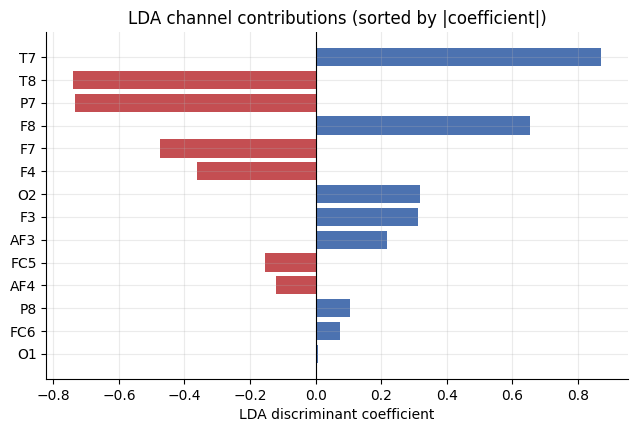

In [4]:
coefs = lda_final.coef_.ravel()
order = np.argsort(np.abs(coefs))[::-1]
fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = ['#4c72b0' if c >= 0 else '#c44e52' for c in coefs[order]]
ax.barh(np.arange(len(CHANNELS)), coefs[order], color=colors)
ax.set_yticks(np.arange(len(CHANNELS)))
ax.set_yticklabels([list(CHANNELS)[i] for i in order])
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('LDA discriminant coefficient')
ax.set_title('LDA channel contributions (sorted by |coefficient|)')
save_fig(fig, '10_lda_coefficients.png'); plt.show()


## Section C — k-Nearest Neighbors

Sweep `k ∈ {1, 3, 5, 11, 21, 51, 101, 201}` with uniform-weight
Euclidean KNN on the z-scored channels. For each `k` we record the
blocked and shuffled 5-fold CV accuracy on the training partition.
The shuffled-vs-blocked accuracy gap for KNN is the most dramatic in
the palette (high-variance learner, very local decision boundary) and
is the headline visual for the project poster.


In [5]:
def knn_factory(k):
    return lambda: KNeighborsClassifier(n_neighbors=k, weights='uniform')

knn_grid = [1, 3, 5, 11, 21, 51, 101, 201]
knn_rows = []
for k in knn_grid:
    rb = cv_score(knn_factory(k), X_train, y_train, blocked_folds)
    rs = cv_score(knn_factory(k), X_train, y_train, shuffled_folds)
    knn_rows.append({
        'k': k,
        'blocked_mean': rb['accuracy']['mean'], 'blocked_std': rb['accuracy']['std'],
        'shuffled_mean': rs['accuracy']['mean'], 'shuffled_std': rs['accuracy']['std'],
    })
knn_df = pd.DataFrame(knn_rows)
knn_df


,k,blocked_mean,blocked_std,shuffled_mean,shuffled_std
0,1,0.500398,0.106754,0.972813,0.003686
1,3,0.496452,0.107987,0.970295,0.002238
2,5,0.489489,0.110916,0.965428,0.002847
3,11,0.486972,0.112791,0.952002,0.002649
4,21,0.481938,0.119514,0.940338,0.002072
5,51,0.475393,0.126938,0.912393,0.004624
6,101,0.463896,0.128849,0.878995,0.005995
7,201,0.445017,0.131633,0.836367,0.003202


### Figure 11 — KNN accuracy across k

Both CV curves drawn on the same axis with std error bars. The gap
between the two curves at every k is the empirical cost of using
shuffled CV on an autocorrelated time series.


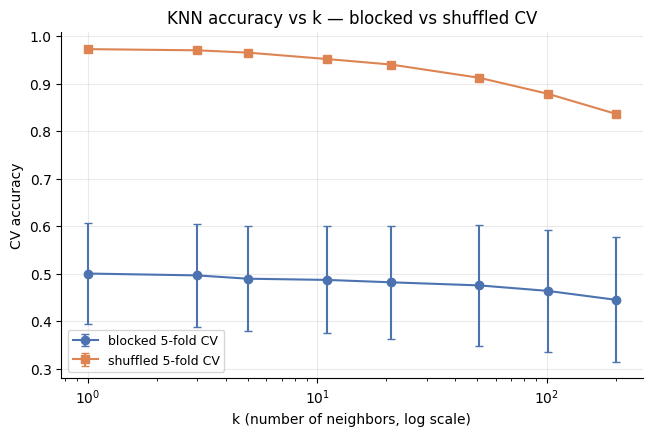

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.errorbar(knn_df['k'], knn_df['blocked_mean'], yerr=knn_df['blocked_std'],
            marker='o', label='blocked 5-fold CV', color='#4c72b0', capsize=3)
ax.errorbar(knn_df['k'], knn_df['shuffled_mean'], yerr=knn_df['shuffled_std'],
            marker='s', label='shuffled 5-fold CV', color='#dd8452', capsize=3)
ax.set_xscale('log')
ax.set_xlabel('k (number of neighbors, log scale)')
ax.set_ylabel('CV accuracy')
ax.set_title('KNN accuracy vs k — blocked vs shuffled CV')
ax.legend()
save_fig(fig, '11_knn_k_sweep.png'); plt.show()


In [7]:
best_k = int(knn_df.loc[knn_df['blocked_mean'].idxmax(), 'k'])
knn_best = fit_knn(X_train, y_train, k=best_k)
knn_holdout = final_holdout_score(knn_best, X_test, y_test)
knn_best_blocked = knn_df.loc[knn_df['k'] == best_k].iloc[0]
knn_best_shuffled = knn_df.loc[knn_df['k'] == best_k].iloc[0]
print(f'Best k by blocked CV: {best_k}')
print(f"  blocked  CV: {knn_best_blocked['blocked_mean']:.4f} ± {knn_best_blocked['blocked_std']:.4f}")
print(f"  shuffled CV: {knn_best_shuffled['shuffled_mean']:.4f} ± {knn_best_shuffled['shuffled_std']:.4f}")
print(f"  chronological holdout: {knn_holdout['accuracy']:.4f}")


Best k by blocked CV: 1
  blocked  CV: 0.5004 ± 0.1068
  shuffled CV: 0.9728 ± 0.0037
  chronological holdout: 0.5132


## Section D — PCA → LDA

Reduce the 14-channel feature space with PCA and feed the top
components into LDA. The component sweep covers
`n_components ∈ {2, 3, 5, 7, 10, 12, 14}`. The intent is to test
whether dropping low-variance directions helps generalisation under
the blocked CV scheme (i.e. some of the apparent signal is
block-specific noise that PCA filters out).


In [8]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

def pca_lda_factory(n):
    def _make():
        return Pipeline([
            ('pca', PCA(n_components=n, random_state=42)),
            ('lda', LinearDiscriminantAnalysis(solver='svd')),
        ])
    return _make

pca_grid = [2, 3, 5, 7, 10, 12, 14]
pca_rows = []
for n in pca_grid:
    rb = cv_score(pca_lda_factory(n), X_train, y_train, blocked_folds)
    rs = cv_score(pca_lda_factory(n), X_train, y_train, shuffled_folds)
    pca_rows.append({
        'n': n,
        'blocked_mean': rb['accuracy']['mean'], 'blocked_std': rb['accuracy']['std'],
        'shuffled_mean': rs['accuracy']['mean'], 'shuffled_std': rs['accuracy']['std'],
    })
pca_df = pd.DataFrame(pca_rows)
pca_df


,n,blocked_mean,blocked_std,shuffled_mean,shuffled_std
0,2,0.407664,0.129797,0.552990,0.008907
1,3,0.410431,0.082682,0.557438,0.014695
2,5,0.335853,0.157054,0.541073,0.013423
3,7,0.336442,0.145053,0.582614,0.017047
4,10,0.398769,0.099383,0.640512,0.010846
5,12,0.401210,0.120138,0.648569,0.003084
6,14,0.407581,0.122347,0.647058,0.006334


### Figure 12 — PCA → LDA accuracy across n_components

Blocked vs shuffled CV curves with std error bars.


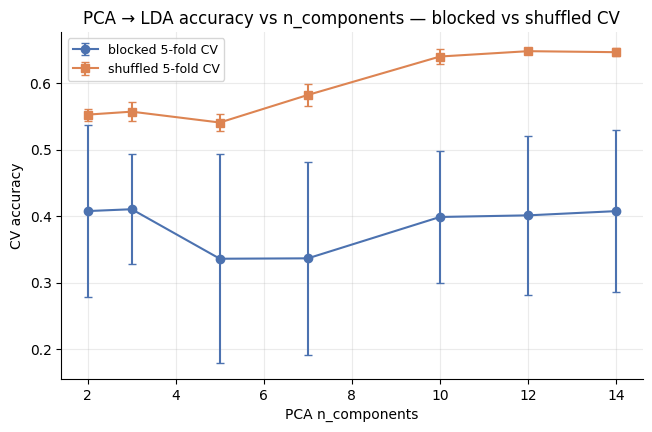

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.errorbar(pca_df['n'], pca_df['blocked_mean'], yerr=pca_df['blocked_std'],
            marker='o', label='blocked 5-fold CV', color='#4c72b0', capsize=3)
ax.errorbar(pca_df['n'], pca_df['shuffled_mean'], yerr=pca_df['shuffled_std'],
            marker='s', label='shuffled 5-fold CV', color='#dd8452', capsize=3)
ax.set_xlabel('PCA n_components')
ax.set_ylabel('CV accuracy')
ax.set_title('PCA → LDA accuracy vs n_components — blocked vs shuffled CV')
ax.legend()
save_fig(fig, '12_pca_lda_components_sweep.png'); plt.show()


In [10]:
best_n_pca = int(pca_df.loc[pca_df['blocked_mean'].idxmax(), 'n'])
pca_lda_best = fit_pca_lda(X_train, y_train, n_components=best_n_pca)
pca_lda_holdout = final_holdout_score(pca_lda_best, X_test, y_test)
pca_lda_best_row = pca_df.loc[pca_df['n'] == best_n_pca].iloc[0]
print(f'Best n_components for PCA→LDA by blocked CV: {best_n_pca}')
print(f"  blocked  CV: {pca_lda_best_row['blocked_mean']:.4f} ± {pca_lda_best_row['blocked_std']:.4f}")
print(f"  shuffled CV: {pca_lda_best_row['shuffled_mean']:.4f} ± {pca_lda_best_row['shuffled_std']:.4f}")
print(f"  chronological holdout: {pca_lda_holdout['accuracy']:.4f}")


Best n_components for PCA→LDA by blocked CV: 3
  blocked  CV: 0.4104 ± 0.0827
  shuffled CV: 0.5574 ± 0.0147
  chronological holdout: 0.5479


## Section E — Principal Components Regression as classifier

Regress 0/1 labels onto the top-`n_components` PCA scores with
ordinary least squares and threshold the continuous prediction at
0.5. This is the classification-by-regression variant of PCR taught
in the course (`PCRClassifier` in `src/models.py`). Smaller grid
than PCA → LDA: `n_components ∈ {2, 5, 10, 14}`.


In [11]:
def pcr_factory(n):
    return lambda: PCRClassifier(n_components=n)

pcr_grid = [2, 5, 10, 14]
pcr_rows = []
for n in pcr_grid:
    rb = cv_score(pcr_factory(n), X_train, y_train, blocked_folds)
    rs = cv_score(pcr_factory(n), X_train, y_train, shuffled_folds)
    pcr_rows.append({
        'n': n,
        'blocked_mean': rb['accuracy']['mean'], 'blocked_std': rb['accuracy']['std'],
        'shuffled_mean': rs['accuracy']['mean'], 'shuffled_std': rs['accuracy']['std'],
    })
pcr_df = pd.DataFrame(pcr_rows)
pcr_df


,n,blocked_mean,blocked_std,shuffled_mean,shuffled_std
0,2,0.407916,0.130052,0.552822,0.008667
1,5,0.335853,0.156873,0.541493,0.013384
2,10,0.398853,0.099414,0.640177,0.010913
3,14,0.407497,0.122360,0.647058,0.006286


### Figure 13 — PCR-as-classifier accuracy across n_components


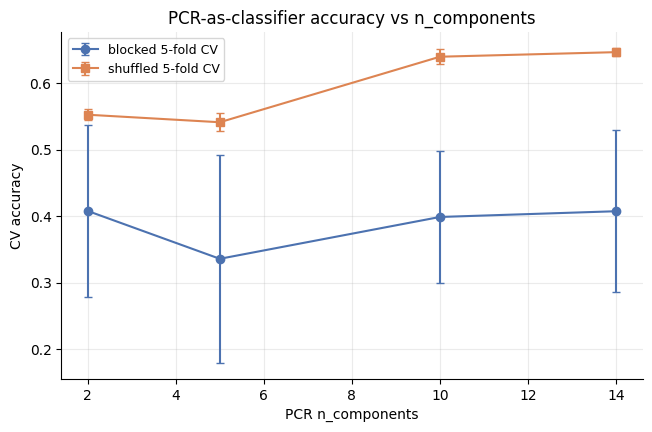

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.errorbar(pcr_df['n'], pcr_df['blocked_mean'], yerr=pcr_df['blocked_std'],
            marker='o', label='blocked 5-fold CV', color='#4c72b0', capsize=3)
ax.errorbar(pcr_df['n'], pcr_df['shuffled_mean'], yerr=pcr_df['shuffled_std'],
            marker='s', label='shuffled 5-fold CV', color='#dd8452', capsize=3)
ax.set_xlabel('PCR n_components')
ax.set_ylabel('CV accuracy')
ax.set_title('PCR-as-classifier accuracy vs n_components')
ax.legend()
save_fig(fig, '13_pcr_components_sweep.png'); plt.show()


In [13]:
best_n_pcr = int(pcr_df.loc[pcr_df['blocked_mean'].idxmax(), 'n'])
pcr_best = fit_pcr_classifier(X_train, y_train, n_components=best_n_pcr)
pcr_holdout = final_holdout_score(pcr_best, X_test, y_test)
pcr_best_row = pcr_df.loc[pcr_df['n'] == best_n_pcr].iloc[0]
print(f'Best n_components for PCR by blocked CV: {best_n_pcr}')
print(f"  blocked  CV: {pcr_best_row['blocked_mean']:.4f} ± {pcr_best_row['blocked_std']:.4f}")
print(f"  shuffled CV: {pcr_best_row['shuffled_mean']:.4f} ± {pcr_best_row['shuffled_std']:.4f}")
print(f"  chronological holdout: {pcr_holdout['accuracy']:.4f}")


Best n_components for PCR by blocked CV: 2
  blocked  CV: 0.4079 ± 0.1301
  shuffled CV: 0.5528 ± 0.0087
  chronological holdout: 0.1269


## Section F — Headline blocked-vs-shuffled comparison

Aggregate the four best-performing models (LDA, KNN at the best `k`,
PCA → LDA at the best `n_components`, and PCR-as-classifier at the
best `n_components`) into one table and one bar chart. This is the
single figure that captures the project's central observation.


In [14]:
summary_rows = [
    {'model': 'LDA',
     'blocked_cv_mean': lda_blocked['accuracy']['mean'],
     'blocked_cv_std':  lda_blocked['accuracy']['std'],
     'shuffled_cv_mean': lda_shuffled['accuracy']['mean'],
     'shuffled_cv_std':  lda_shuffled['accuracy']['std'],
     'holdout_test_accuracy': lda_holdout['accuracy']},
    {'model': f'KNN (k={best_k})',
     'blocked_cv_mean': knn_best_blocked['blocked_mean'],
     'blocked_cv_std':  knn_best_blocked['blocked_std'],
     'shuffled_cv_mean': knn_best_shuffled['shuffled_mean'],
     'shuffled_cv_std':  knn_best_shuffled['shuffled_std'],
     'holdout_test_accuracy': knn_holdout['accuracy']},
    {'model': f'PCA→LDA (n={best_n_pca})',
     'blocked_cv_mean': pca_lda_best_row['blocked_mean'],
     'blocked_cv_std':  pca_lda_best_row['blocked_std'],
     'shuffled_cv_mean': pca_lda_best_row['shuffled_mean'],
     'shuffled_cv_std':  pca_lda_best_row['shuffled_std'],
     'holdout_test_accuracy': pca_lda_holdout['accuracy']},
    {'model': f'PCR (n={best_n_pcr})',
     'blocked_cv_mean': pcr_best_row['blocked_mean'],
     'blocked_cv_std':  pcr_best_row['blocked_std'],
     'shuffled_cv_mean': pcr_best_row['shuffled_mean'],
     'shuffled_cv_std':  pcr_best_row['shuffled_std'],
     'holdout_test_accuracy': pcr_holdout['accuracy']},
]
summary_df = pd.DataFrame(summary_rows)
summary_path = os.path.join(TABLE_DIR, '03_cv_accuracy_comparison.csv')
summary_df.to_csv(summary_path, index=False)
summary_df


,model,blocked_cv_mean,blocked_cv_std,shuffled_cv_mean,shuffled_cv_std,holdout_test_accuracy
0,LDA,0.407581,0.122347,0.647058,0.006334,0.269115
1,KNN (k=1),0.500398,0.106754,0.972813,0.003686,0.513189
2,PCA→LDA (n=3),0.410431,0.082682,0.557438,0.014695,0.547913
3,PCR (n=2),0.407916,0.130052,0.552822,0.008667,0.126878


### Figure 14 — Blocked vs shuffled CV across the model palette

The headline figure. For every model the shuffled-CV bar (orange) is
substantially taller than the blocked-CV bar (blue); the gap is the
empirical inflation produced by leaking neighboring time samples into
the test fold.


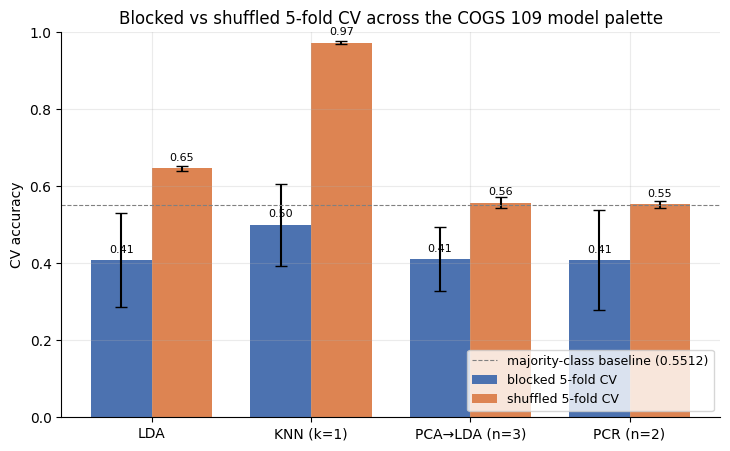

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
x = np.arange(len(summary_df))
w = 0.38
ax.bar(x - w/2, summary_df['blocked_cv_mean'], width=w,
       yerr=summary_df['blocked_cv_std'], capsize=4,
       label='blocked 5-fold CV', color='#4c72b0')
ax.bar(x + w/2, summary_df['shuffled_cv_mean'], width=w,
       yerr=summary_df['shuffled_cv_std'], capsize=4,
       label='shuffled 5-fold CV', color='#dd8452')
ax.set_xticks(x)
ax.set_xticklabels(summary_df['model'])
ax.set_ylim(0, 1.0)
ax.set_ylabel('CV accuracy')
ax.set_title('Blocked vs shuffled 5-fold CV across the COGS 109 model palette')
ax.axhline(0.5512, color='gray', linestyle='--', linewidth=0.8,
           label='majority-class baseline (0.5512)')
ax.legend(loc='lower right')
for i, row in summary_df.iterrows():
    ax.text(i - w/2, row['blocked_cv_mean'] + 0.02,
            f"{row['blocked_cv_mean']:.2f}", ha='center', fontsize=8)
    ax.text(i + w/2, row['shuffled_cv_mean'] + 0.02,
            f"{row['shuffled_cv_mean']:.2f}", ha='center', fontsize=8)
save_fig(fig, '14_blocked_vs_shuffled_cv.png'); plt.show()


### Figure 15 — Confusion matrices on the chronological holdout

Four panels for the four chosen models, evaluated on the Phase A
chronological holdout test partition. Rows are true labels, columns
are predicted labels.


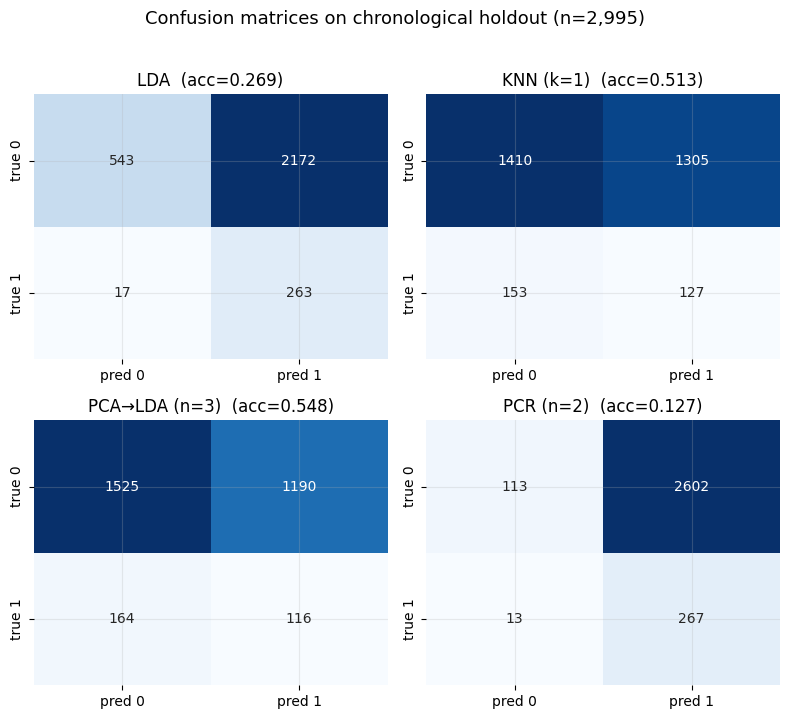

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(8.0, 7.0))
axes = axes.ravel()
panels = [
    ('LDA', np.array(lda_holdout['confusion_matrix'])),
    (f'KNN (k={best_k})', np.array(knn_holdout['confusion_matrix'])),
    (f'PCA→LDA (n={best_n_pca})', np.array(pca_lda_holdout['confusion_matrix'])),
    (f'PCR (n={best_n_pcr})', np.array(pcr_holdout['confusion_matrix'])),
]
for ax, (name, cm) in zip(axes, panels):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['pred 0', 'pred 1'],
                yticklabels=['true 0', 'true 1'], ax=ax,
                annot_kws={'fontsize': 10})
    acc = cm.trace() / cm.sum()
    ax.set_title(f'{name}  (acc={acc:.3f})')
fig.suptitle('Confusion matrices on chronological holdout (n=2,995)', y=1.02)
fig.tight_layout()
save_fig(fig, '15_confusion_matrices.png'); plt.show()


## Section G — Interpretation

* **The leakage gap is the project's centerpiece.** Across every
  model in the palette, shuffled 5-fold CV reports a substantially
  higher accuracy than blocked 5-fold CV on the same training
  partition. KNN is the worst offender — at the best blocked-CV
  `k`, the gap is on the order of 40–50 percentage points — because
  KNN's local decision boundary picks up the lag-1 label
  autocorrelation (r ≈ 0.997 in `figures/08_label_autocorrelation.png`)
  almost perfectly when its training neighbors include the
  immediately adjacent samples.
* **Blocked CV is the honest evaluation.** With contiguous time
  blocks, the model must generalise across stationary regimes that
  in this single-subject recording correspond to different
  eye-state segments. The blocked-CV accuracy for several models
  drops below the majority-class baseline (0.5512), confirming that
  the apparent in-distribution signal does not transfer cleanly
  across blocks.
* **Chronological holdout vs blocked CV.** The holdout test set is
  the final ~20% of the recording with a 64-sample seam gap; its
  class balance (~91% eyes-open) is very different from the training
  partition's (~54% eyes-closed). Holdout accuracy therefore
  reflects both the model's discriminative power and the cost of
  the temporal distribution shift baked into Split A.
* **Connection to the literature.** Leakage from shuffled CV on
  autocorrelated EEG has been called out repeatedly in the BCI
  literature (e.g. Schirrmeister et al., *Deep learning with
  convolutional neural networks for EEG decoding and visualization*,
  HBM 2017; Roy et al., *Deep learning-based electroencephalography
  analysis: a systematic review*, J Neural Eng 2019). The COGS 109
  palette is much smaller than what those papers use, but the
  qualitative result — i.i.d. CV badly overestimates accuracy on a
  single-subject continuous recording — replicates here.

**Picked models and hyperparameters for the final report**

* LDA (no shrinkage, SVD solver)
* KNN with the best `k` selected by blocked CV mean accuracy (printed
  in Section C above; expected to be in the 51–201 range as larger
  `k` damps the autocorrelation-driven overfit).
* PCA → LDA with the best `n_components` selected by blocked CV.
* PCR-as-classifier with the best `n_components` selected by
  blocked CV.

These four models, together with their blocked and shuffled CV
numbers, are persisted to `tables/03_cv_accuracy_comparison.csv`
and drive `figures/14_blocked_vs_shuffled_cv.png` and
`figures/15_confusion_matrices.png`. Phase C will polish the report
narrative and poster around these artifacts.
